<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/5.0%20Churn_Model_Selection%20and%20Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

query = """
SELECT "CustomerID",
    "Recency",
    "Frequency",
    "TotalRevenue" AS "Monetary",
    "ObservedLifeSpan",
    "Tenure",
    "ProductDiversity",
    "CohortMonth",
    "KSegment",
    "Churned"
FROM v_customer_metrics
INNER JOIN (SELECT "CustomerID",
            "Churned"
              FROM v_churn_analysis_candidates)
USING("CustomerID")
LEFT JOIN (SELECT "CustomerID",
          "KSegment"
          FROM customer_segment_labels)
USING("CustomerID")
"""

df = pd.read_sql(text(query), con = engine).dropna()
df['KSegment'] = df['KSegment'].astype('str')
print("Preview of sql query:")
print(df.isna().sum())
print(df.info())
df.head()

Preview of sql query:
CustomerID          0
Recency             0
Frequency           0
Monetary            0
ObservedLifeSpan    0
Tenure              0
ProductDiversity    0
CohortMonth         0
KSegment            0
Churned             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 2908 entries, 0 to 2907
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        2908 non-null   float64
 1   Recency           2908 non-null   int64  
 2   Frequency         2908 non-null   int64  
 3   Monetary          2908 non-null   float64
 4   ObservedLifeSpan  2908 non-null   int64  
 5   Tenure            2908 non-null   int64  
 6   ProductDiversity  2908 non-null   int64  
 7   CohortMonth       2908 non-null   object 
 8   KSegment          2908 non-null   object 
 9   Churned           2908 non-null   int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 249.9+ KB
None


,CustomerID,Recency,Frequency,Monetary,ObservedLifeSpan,Tenure,ProductDiversity,CohortMonth,KSegment,Churned
0,12347.0,129,5,22.506935,238,367,82,2010-12,0.0,0
1,12348.0,248,3,53.115714,110,358,22,2010-12,3.0,1
2,12350.0,310,1,19.670588,0,310,17,2011-02,3.0,1
3,12352.0,262,4,41.100263,34,296,26,2011-02,3.0,1
4,12353.0,204,1,22.250000,0,204,4,2011-05,4.0,1


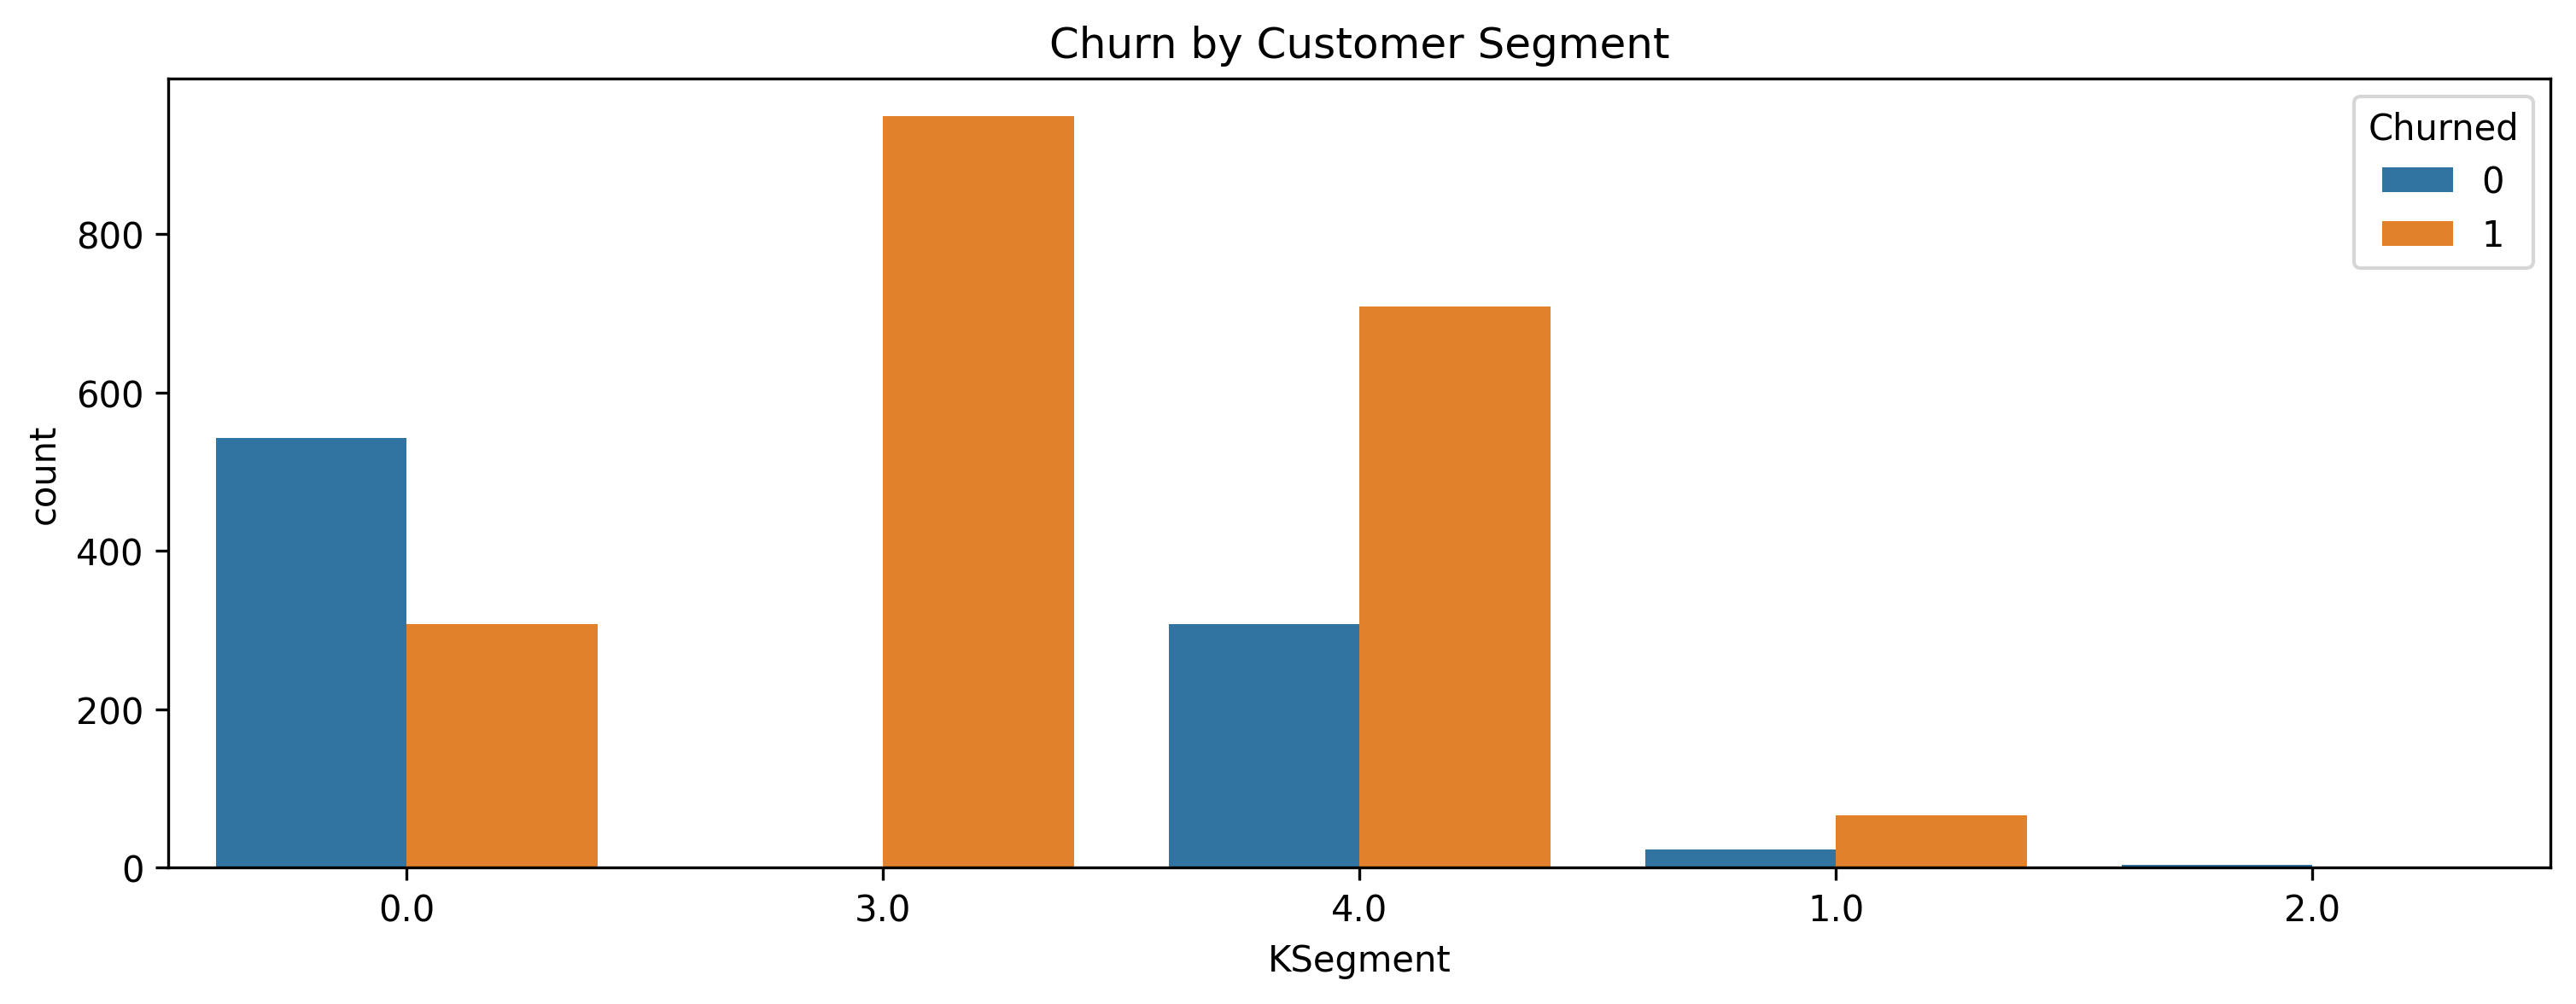

KSegment,0.0,1.0,2.0,3.0,4.0
Churned,,,,,
0,543.0,23.0,3.0,NaN,307.0
1,308.0,66.0,NaN,949.0,709.0


In [105]:
plt.figure(figsize = (12,4), dpi = 300)
sns.countplot(data = df, x = 'KSegment', hue = 'Churned')
plt.title("Churn by Customer Segment")
plt.show()

df.groupby(['KSegment', 'Churned']).size().unstack(level= 0)

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = df.drop(['Churned', 'CustomerID', 'KSegment', 'CohortMonth'], axis = 1)
X = pd.get_dummies(X, drop_first = True)
features = X.columns
X = X.values

y = df['Churned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

scaler = StandardScaler()

models = [("Logistic Regression", LogisticRegression(max_iter = 1000, class_weight = 'balanced')),
          ("Random Forest", RandomForestClassifier(n_estimators = 200, max_depth = 20, min_samples_leaf = 2, random_state = 42, class_weight = 'balanced')),
          ("Decision Tree", DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 1, min_samples_split = 2, criterion = 'entropy', random_state = 42, class_weight = 'balanced')),
          ("Xgboost", XGBClassifier(n_estimators = 200, max_depth = 20, learning_rate = 0.05, random_state = 42)),
          ("Lightgbm", LGBMClassifier(n_estimators = 200, max_depth = 20, learning_rate = 0.05, random_state = 42, class_weight = 'balanced'))]

model_name = []
accuracy_avg = []
precision_avg = []
recall_avg = []
for name, model in models:
  pipeline = make_pipeline(scaler, model)
  kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
  accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv = kf, scoring = 'accuracy')
  precision_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'precision')
  recall_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'recall')

  model_name.append(name)
  accuracy_avg.append(accuracy_scores)
  precision_avg.append(precision_scores)
  recall_avg.append(recall_scores)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

/tmp/ipykernel_5182/1547363700.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(accuracy_avg, labels = model_name)
/tmp/ipykernel_5182/1547363700.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(precision_avg, labels = model_name)
/tmp/ipykernel_5182/1547363700.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(recall_avg, labels = model_name)


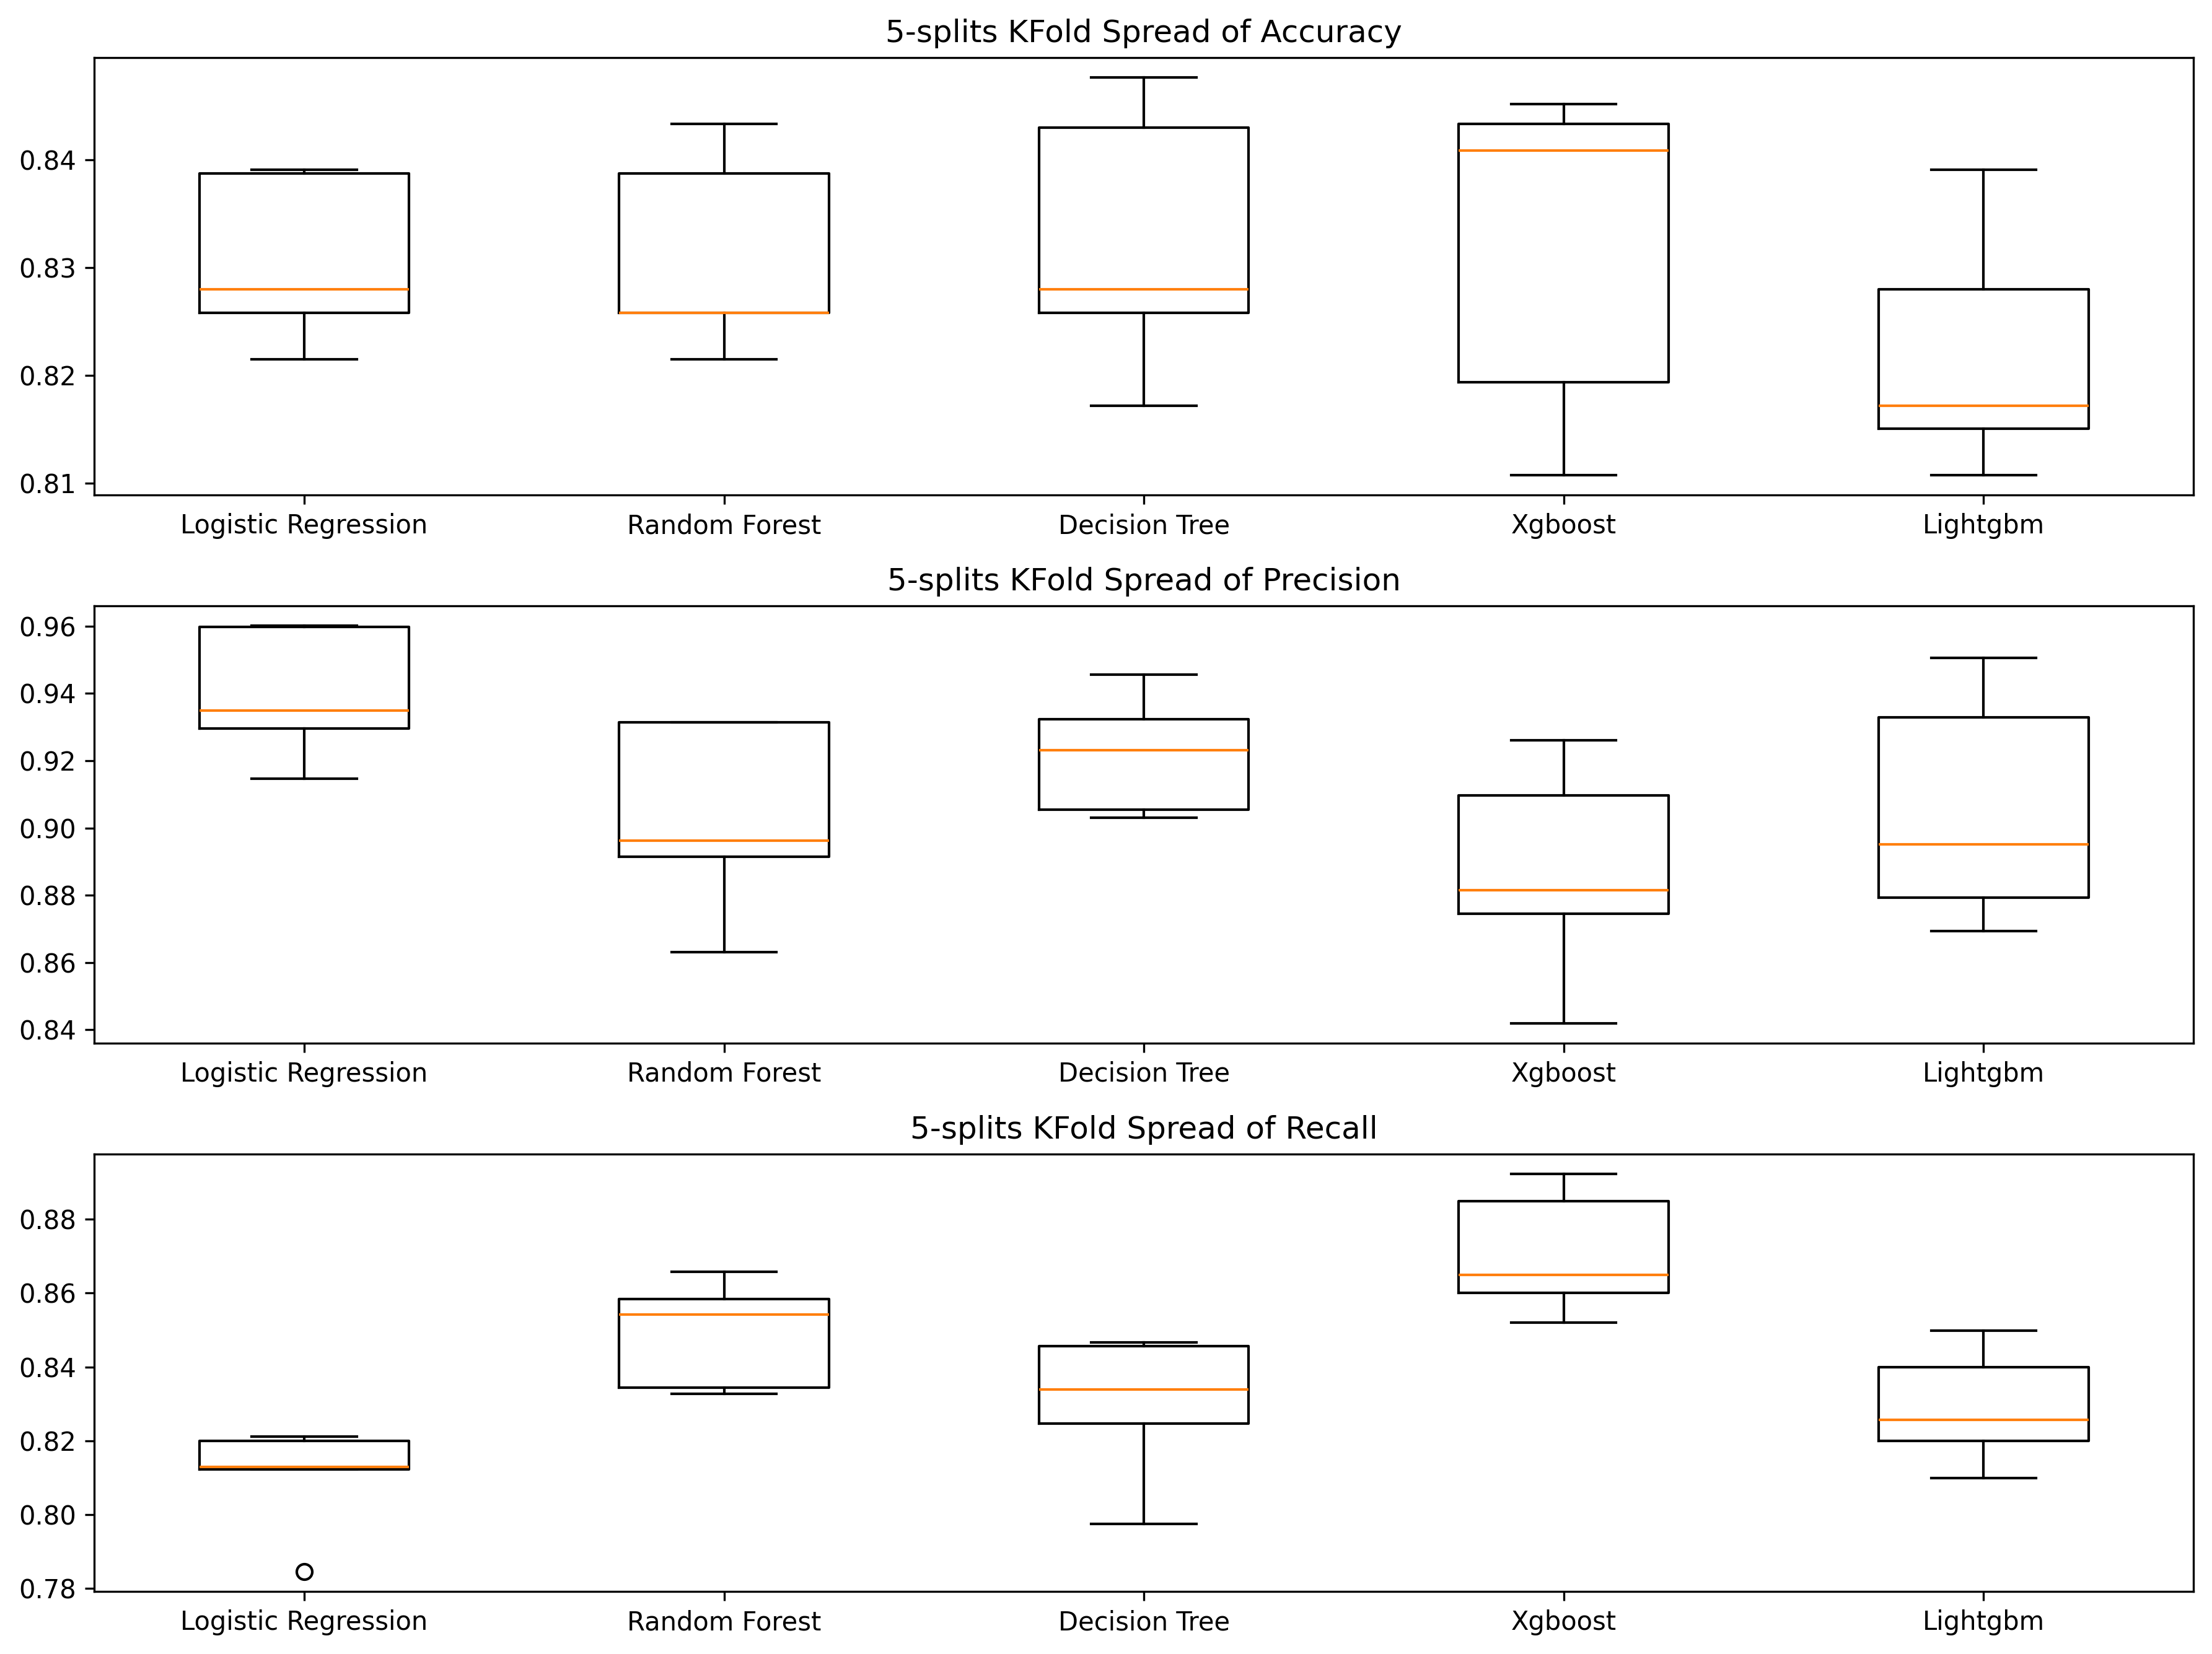

In [107]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize = (12,9), dpi = 300)
ax1.boxplot(accuracy_avg, labels = model_name)
ax1.set_title("5-splits KFold Spread of Accuracy")
ax2.boxplot(precision_avg, labels = model_name)
ax2.set_title("5-splits KFold Spread of Precision")
ax3.boxplot(recall_avg, labels = model_name)
ax3.set_title("5-splits KFold Spread of Recall")
plt.tight_layout()
plt.show()

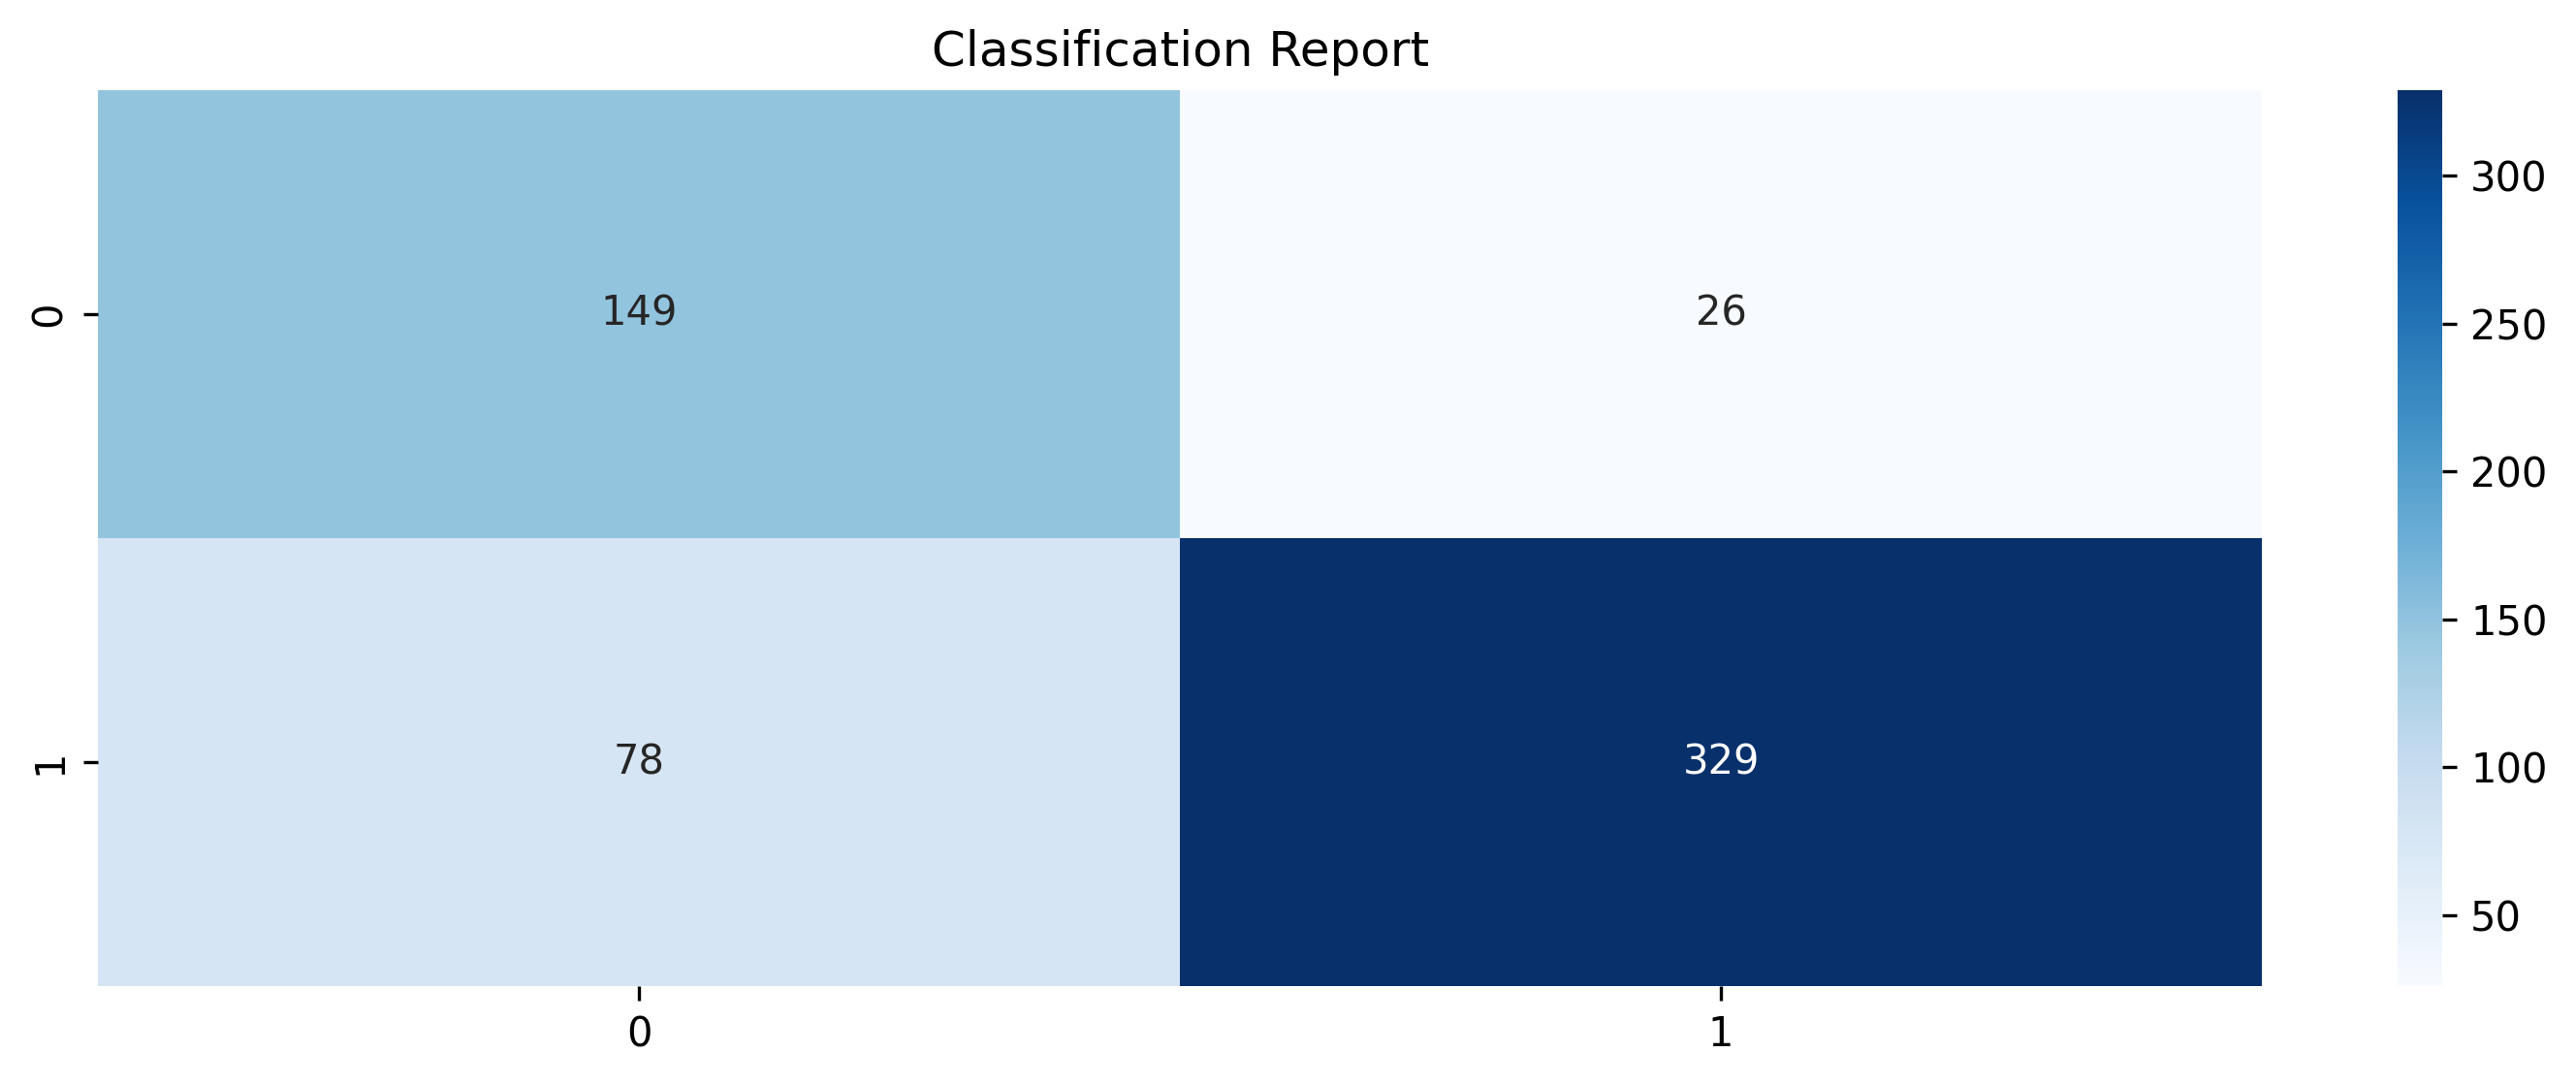

              precision    recall  f1-score   support

           0       0.66      0.85      0.74       175
           1       0.93      0.81      0.86       407

    accuracy                           0.82       582
   macro avg       0.79      0.83      0.80       582
weighted avg       0.85      0.82      0.83       582



In [108]:
model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
#model = RandomForestClassifier(n_estimators = 200, max_depth = 20, min_samples_leaf = 2, random_state = 42, class_weight = 'balanced')
pipeline = make_pipeline(scaler, model)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

c_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(c_matrix, cmap='Blues', annot = True, fmt = 'g')
plt.title("Classification Report")
plt.show()

print(classification_report(y_test, y_pred))

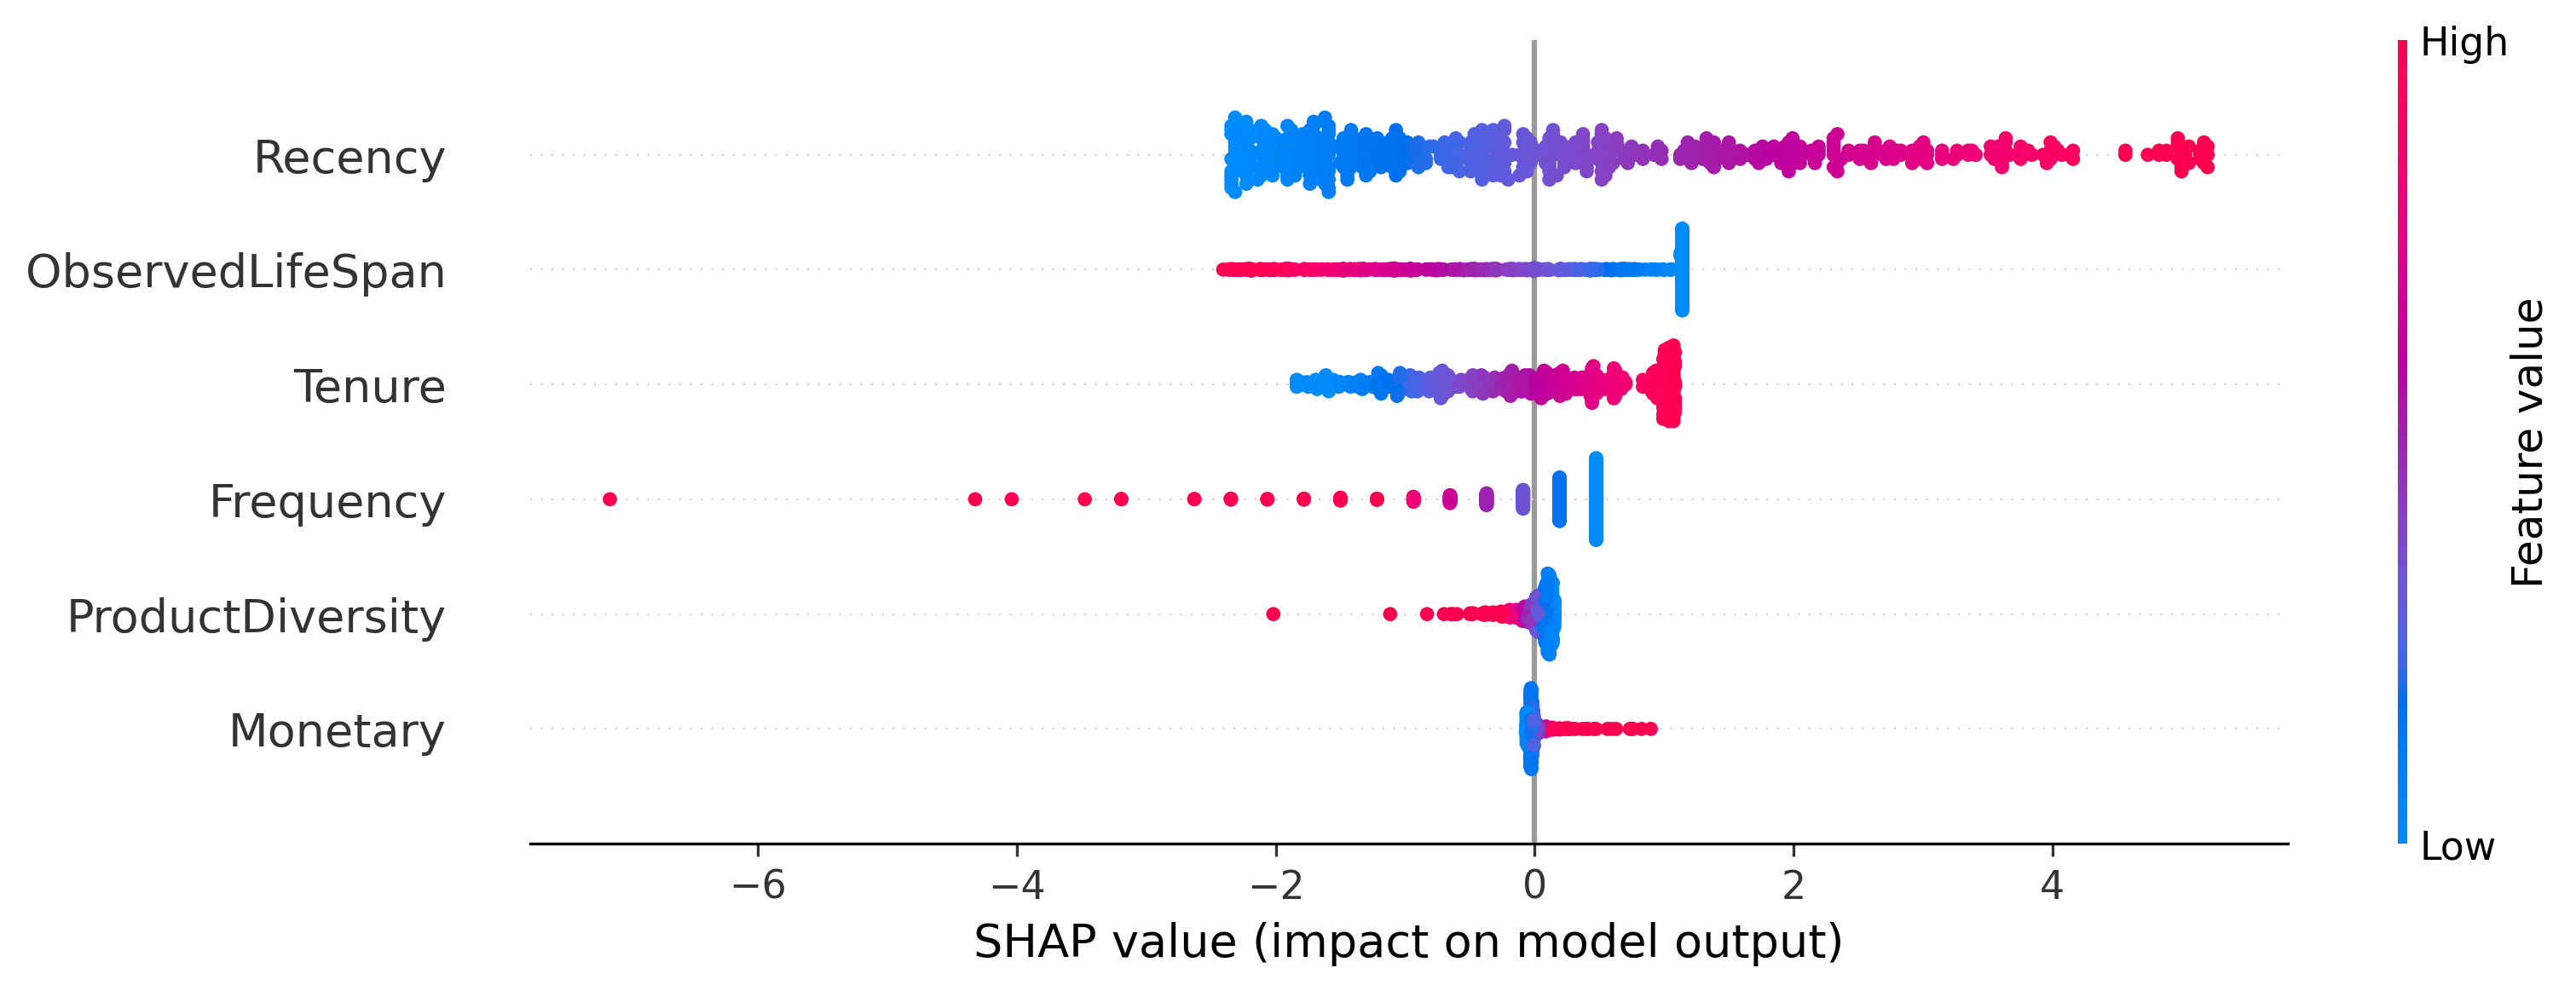

In [109]:
import shap

X_train_scaled_df = pd.DataFrame(scaler.fit_transform(X_train), columns = features)
X_test_scaled_df = pd.DataFrame(scaler.transform(X_test), columns = features)

explainer = shap.LinearExplainer(model, X_train_scaled_df)
#explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_scaled_df)

plt.figure(dpi = 300)
shap.summary_plot(shap_values, X_test_scaled_df, show = False)
#plt.tight_layout()
plt.gcf().set_size_inches(12,4)
plt.show()

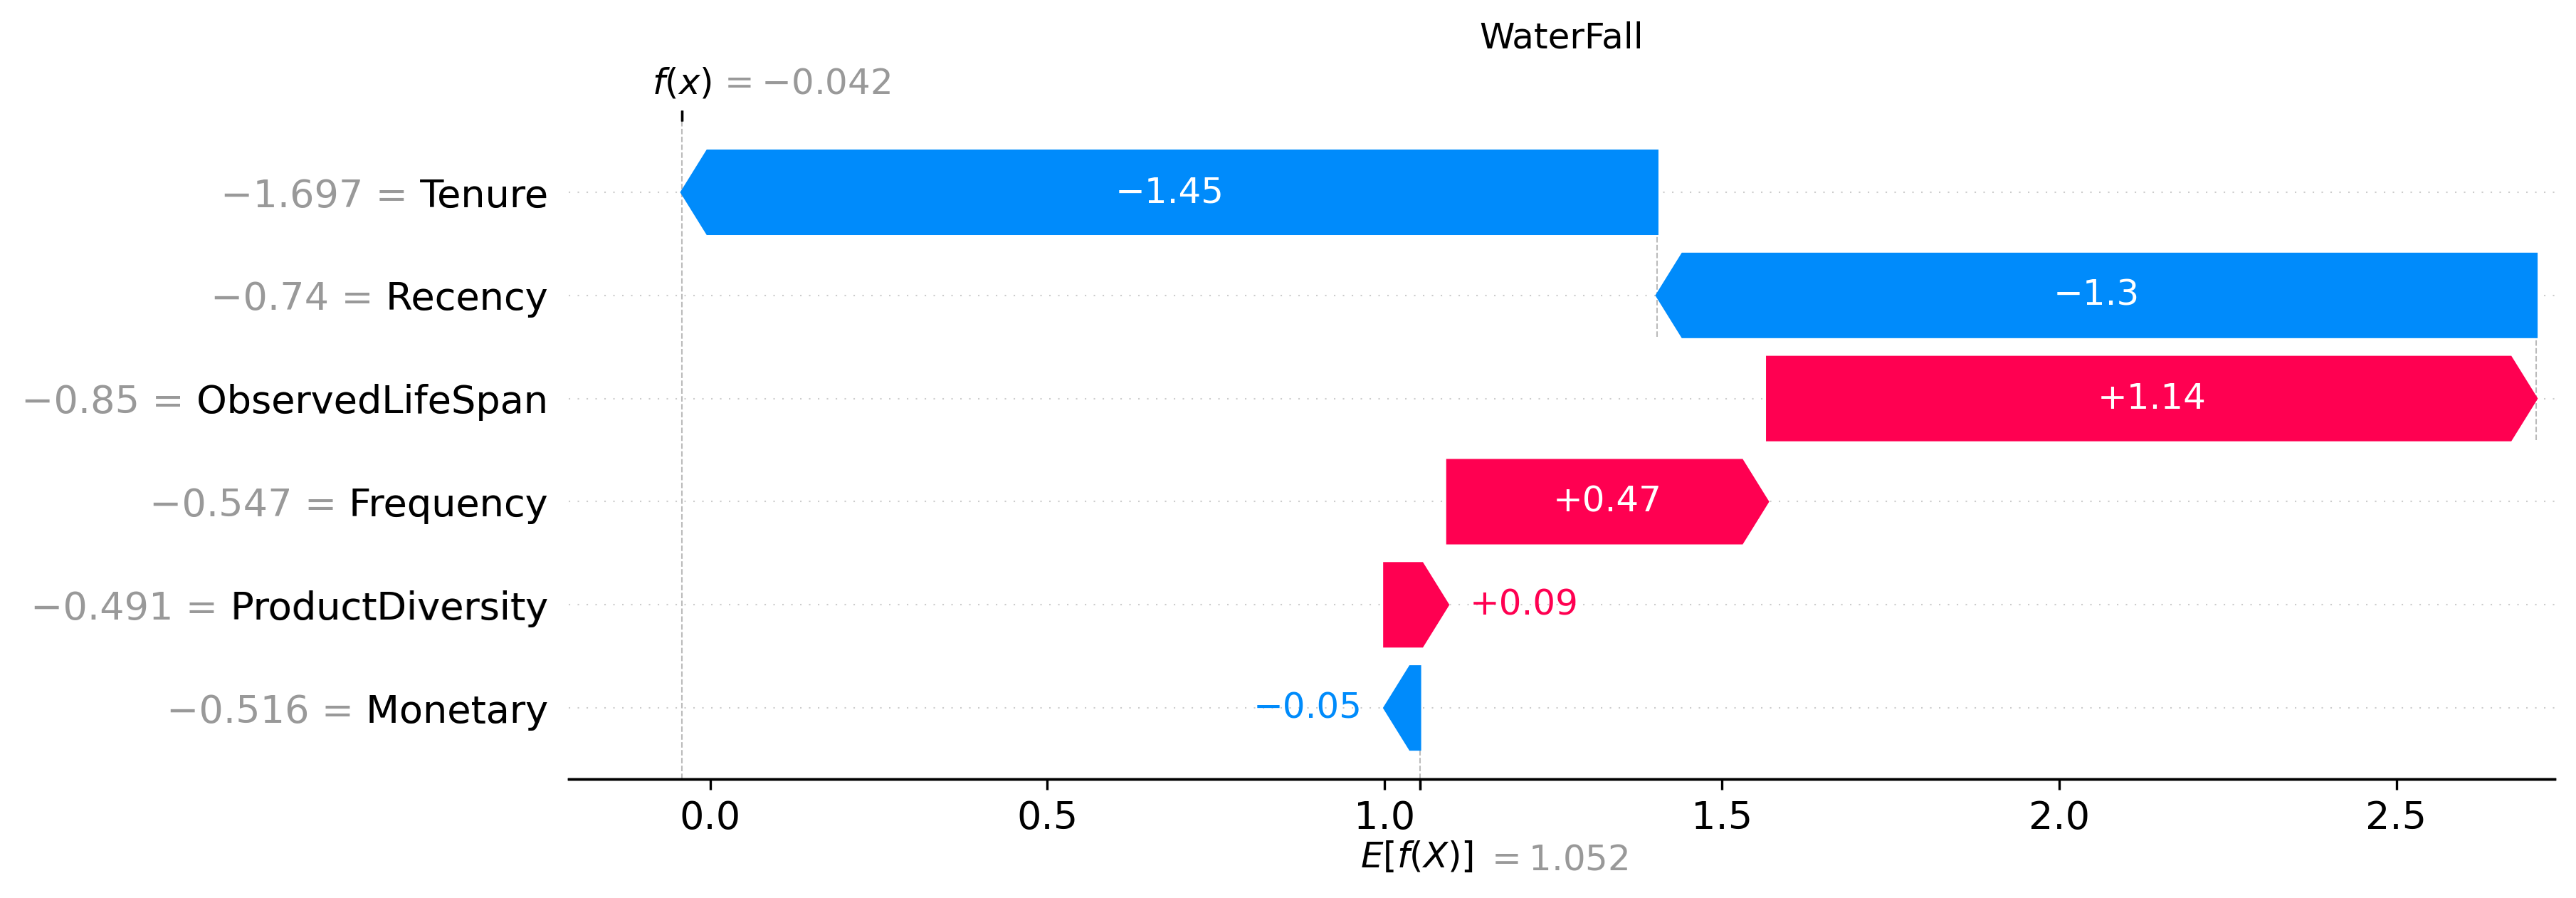

In [110]:
plt.figure(dpi =300)
shap.plots.waterfall(shap_values[0], show = False)
plt.gcf().set_size_inches(12,4)
plt.title("WaterFall")
plt.show()